In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Deep Learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ConvNeXtTiny


In [5]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 445
EPOCHS = 3
SEED = 42

DATASET_DIR = r"D:\AI\8. Deep Learning\Gender Prediction\gender_dataset"

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1668 files belonging to 2 classes.
Using 1335 files for training.
Found 1668 files belonging to 2 classes.
Using 333 files for validation.


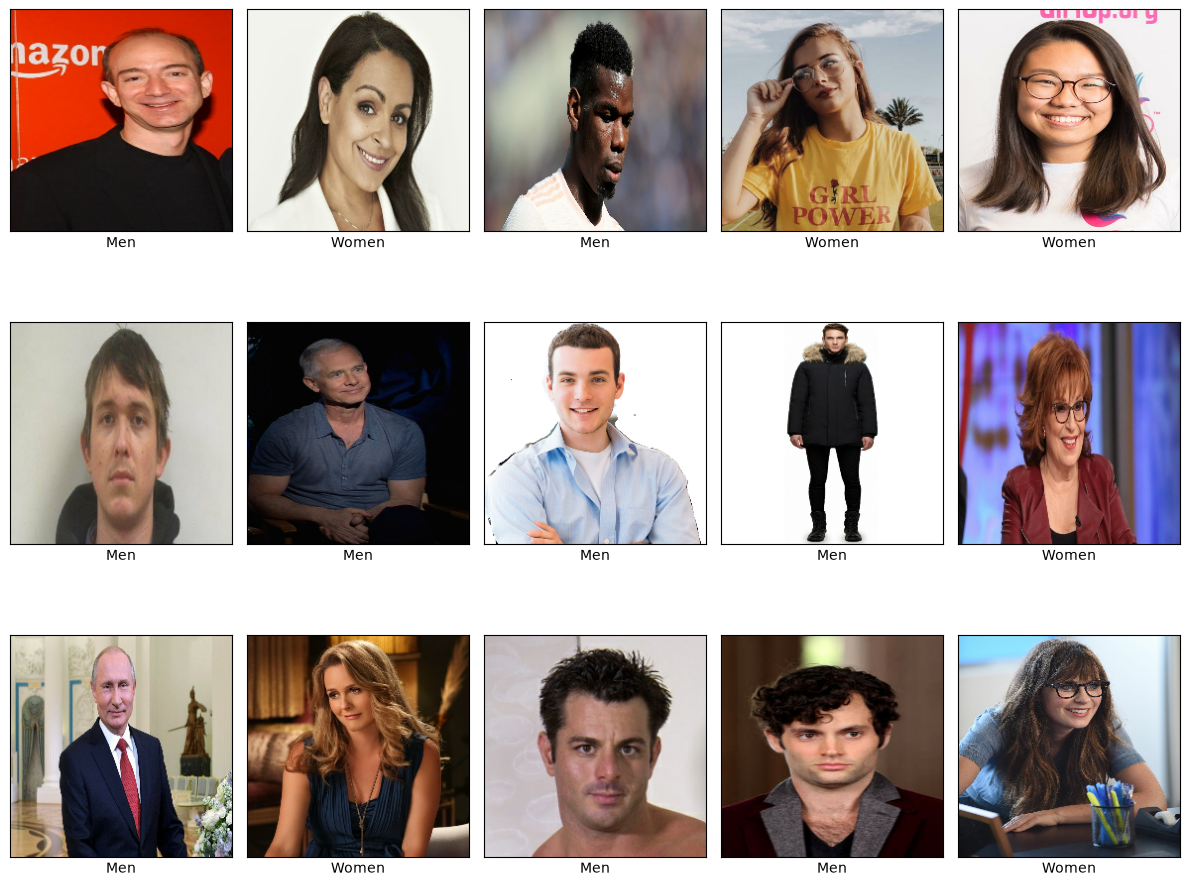

In [7]:
plt.figure(figsize=(12, 10))

class_names=[ "Men", "Women"]


for images, labels in train_dataset.take(1):
    for i in range(15):
        plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.xticks([])
        plt.yticks([])
        label = int(labels[i].numpy()[0])
        plt.xlabel(class_names[label])
plt.tight_layout()
plt.show()

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch( buffer_size=AUTOTUNE)

test_dataset = test_dataset.prefetch( buffer_size=AUTOTUNE)

In [9]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [10]:
base_model = ConvNeXtTiny(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3),
    pooling="avg"
)

# Freeze the pretrained layers initially
base_model.trainable = False

In [11]:
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.Dropout(0.4)(x)
x = layers.Dense( 128,activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

# Binary classification
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ convnext_tiny (Functional)           │ (None, 768)                 │      27,820,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 768)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          98,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,919,201 (106.50 MB)

 Trainable params: 98,817 (386.00 KB)

 Non-trainable params: 27,820,384 (106.13 MB)

In [12]:
model.compile( optimizer=keras.optimizers.Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [13]:
history = model.fit(train_dataset, epochs=EPOCHS, validation_data=test_dataset)

Epoch 1/3


C:\Anaconda3\envs\tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


3/3 ━━━━━━━━━━━━━━━━━━━━ 475s 153s/step - accuracy: 0.5131 - loss: 0.9838 - val_accuracy: 0.6066 - val_loss: 0.7268
Epoch 2/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 400s 142s/step - accuracy: 0.5303 - loss: 0.9021 - val_accuracy: 0.6787 - val_loss: 0.6438
Epoch 3/3
3/3 ━━━━━━━━━━━━━━━━━━━━ 421s 150s/step - accuracy: 0.6037 - loss: 0.7801 - val_accuracy: 0.7357 - val_loss: 0.5730


In [14]:
test_loss, test_accuracy = model.evaluate( test_dataset )

print("ConvNeXt Test Accuracy:", round(test_accuracy, 4))

print("ConvNeXt Test Loss:", round(test_loss, 4))

1/1 ━━━━━━━━━━━━━━━━━━━━ 84s 84s/step - accuracy: 0.7357 - loss: 0.5730
ConvNeXt Test Accuracy: 0.7357
ConvNeXt Test Loss: 0.573


In [15]:
y_true = []
y_pred_probability = []

for images, labels in test_dataset:
    predictions = model.predict( images, verbose=0)
    y_true.extend( labels.numpy().flatten())
    y_pred_probability.extend(predictions.flatten())
    
y_true = np.array(y_true)
y_pred_probability = np.array(y_pred_probability)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probability >= 0.5).astype(int)

In [16]:
accuracy = accuracy_score( y_true, y_pred )

print("Test Accuracy:", round(accuracy, 4))

Test Accuracy: 0.7357


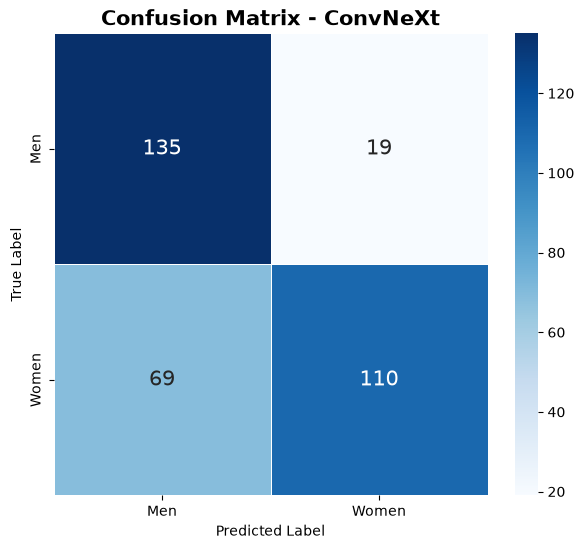

In [17]:
con_mat = confusion_matrix( y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    con_mat,
    annot=True,
    annot_kws={"size": 15},
    linewidths=0.5,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - ConvNeXt",
    fontweight="bold",
    fontsize=15
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [18]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         Men       0.66      0.88      0.75       154
       Women       0.85      0.61      0.71       179

    accuracy                           0.74       333
   macro avg       0.76      0.75      0.73       333
weighted avg       0.76      0.74      0.73       333



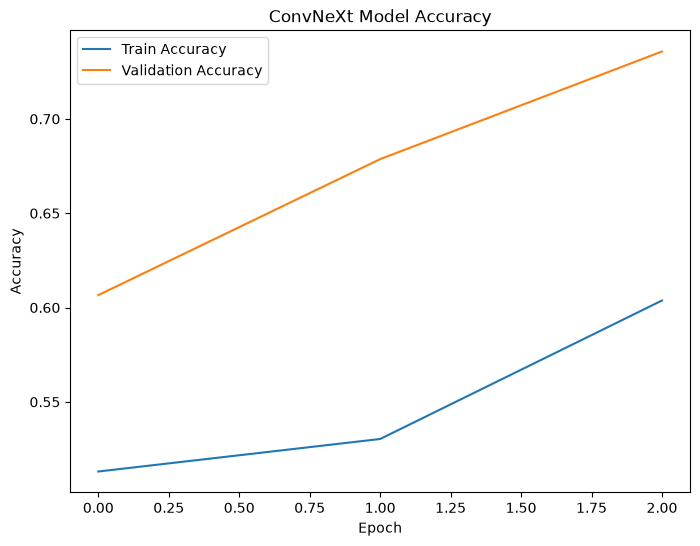

In [19]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ConvNeXt Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(loc="best")
plt.show()

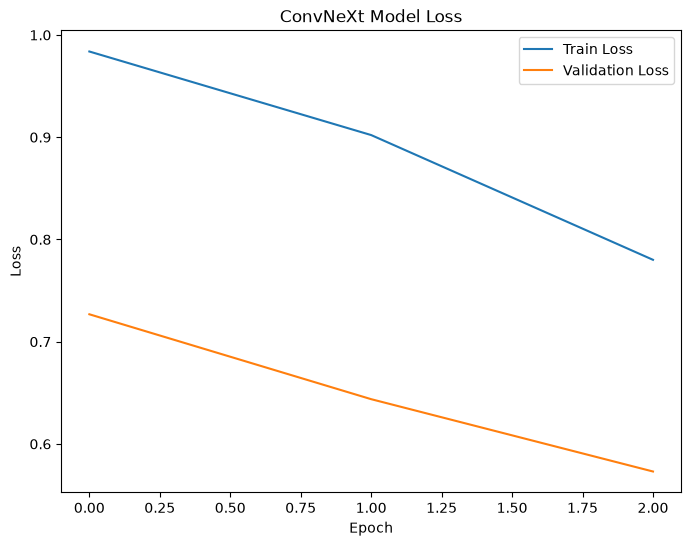

In [20]:
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot( history.history["val_loss"], label="Validation Loss")
plt.title("ConvNeXt Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend( loc="best")
plt.show()

In [24]:
sample_image = "gender_dataset/women/1.jpg"
img = tf.keras.utils.load_img( sample_image, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, axis=0)
prediction = model.predict( img_array, verbose=0)
probability = prediction[0][0]
predicted_class = ( 1 if probability >= 0.5 else 0)
print("Predicted:", class_names[predicted_class])
print("Probability:", round(float(probability), 4))

Predicted: Women
Probability: 0.6102


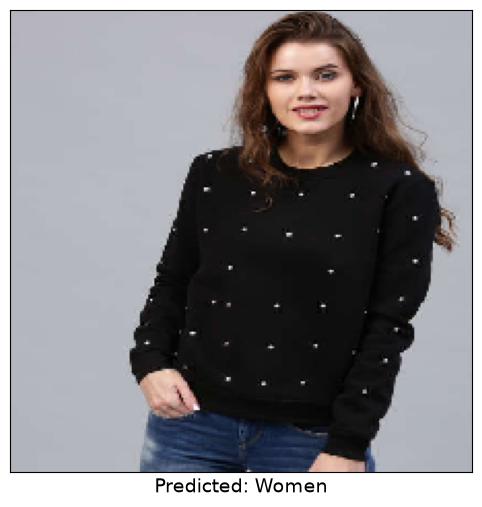

In [25]:
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.xlabel("Predicted: {}".format(class_names[predicted_class]), fontsize=14)
plt.show()

In [ ]:
# ============================================================
# 22. FINE-TUNING CONVNEXT
# ============================================================

base_model.trainable = True

# Keep most layers frozen and fine-tune the later layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile( optimizer=keras.optimizers.Adam( learning_rate=1e-5 ), loss="binary_crossentropy", metrics=["accuracy"])
fine_tune_history = model.fit( train_dataset, epochs=10, validation_data=test_dataset)

Epoch 1/10


C:\Anaconda3\envs\tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
